In [185]:
import pandas as pd

In [186]:
df = pd.read_csv(
    '/content/Comment Toxicity Detection train.csv',
    on_bad_lines='skip'
)

In [187]:
one = df.copy()

In [188]:
one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [189]:
one.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [190]:
one.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [191]:
import re

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove newline
    text = text.replace('\n', ' ')

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text
one['comment_text'] =one['comment_text'].apply(clean_text)

In [192]:
one.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,explanation why the edits made under my userna...,0,0,0,0,0,0
1,000103f0d9cfb60f,daww he matches this background colour im seem...,0,0,0,0,0,0
2,000113f07ec002fd,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,0001b41b1c6bb37e,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,0001d958c54c6e35,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [193]:
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

one['comment_text'] = one['comment_text'].apply(remove_stopwords)

one.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,explanation edits made username hardcore metal...,0,0,0,0,0,0
1,000103f0d9cfb60f,daww matches background colour im seemingly st...,0,0,0,0,0,0
2,000113f07ec002fd,hey man im really trying edit war guy constant...,0,0,0,0,0,0
3,0001b41b1c6bb37e,cant make real suggestions improvement wondere...,0,0,0,0,0,0
4,0001d958c54c6e35,sir hero chance remember page thats,0,0,0,0,0,0


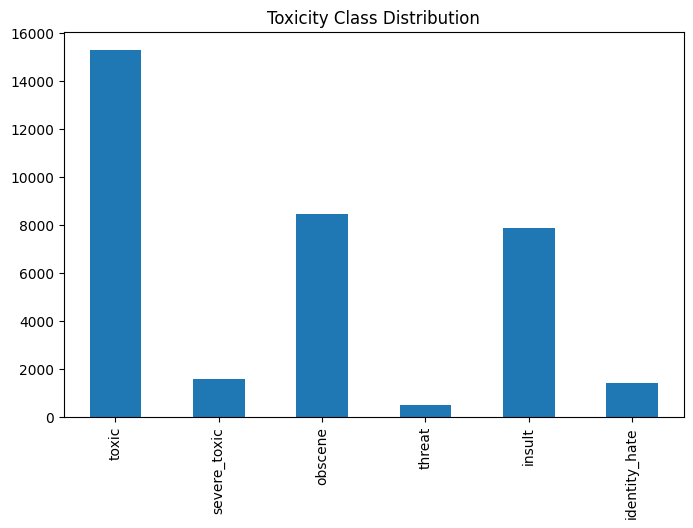

In [194]:
import matplotlib.pyplot as plt

labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

one[labels].sum().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Toxicity Class Distribution")
plt.show()

In [195]:
one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [196]:
one['comment_text'].unique()

array(['explanation edits made username hardcore metallica fan reverted werent vandalisms closure gas voted new york dolls fac please dont remove template talk page since im retired',
       'daww matches background colour im seemingly stuck thanks talk january utc',
       'hey man im really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info',
       ...,
       'spitzer umm theres actual article prostitution ring crunch captain',
       'looks like actually put speedy first version deleted look',
       'really dont think understand came idea bad right away kind community goes bad ideas go away instead helping rewrite'],
      dtype=object)

In [197]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [198]:
tokenizer = Tokenizer(num_words=10000)

In [199]:
X = one['comment_text']

y = one[
    [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
]

In [200]:
tokenizer.fit_on_texts(X)

In [201]:
X_seq = tokenizer.texts_to_sequences(X)
X[0]

X_seq[0]

[523,
 44,
 47,
 513,
 4394,
 920,
 208,
 1884,
 6312,
 2479,
 2633,
 37,
 1009,
 2665,
 5,
 9,
 136,
 300,
 4,
 2,
 58,
 13,
 3210]

In [202]:
lengths = [len(seq) for seq in X_seq]
print(max(lengths))
print(min(lengths))

1250
0


In [203]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [204]:
import numpy as np


lengths = [len(seq) for seq in X_seq]

print(np.percentile(lengths,90))

print(np.percentile(lengths,95))

print(np.percentile(lengths,99))

67.0
102.0
254.0


In [205]:

X_pad = pad_sequences(X_seq, maxlen=200)

print(X_pad.shape)

(159571, 200)


In [206]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [207]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(127656, 200)
(31915, 200)
(127656, 6)
(31915, 6)


In [208]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(31915, 6)

In [209]:
import torch.nn as nn


In [210]:

len(tokenizer.word_index)

223813

In [237]:
#save tokenizer
import pickle

with open(
    "tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

#rnn

In [238]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import Precision
from tensorflow.keras.metrics import Recall


rnn_model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=200
    ),

    SimpleRNN(
        128,
        return_sequences=True
    ),

    Dropout(0.3),

    SimpleRNN(
        64
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        6,
        activation='sigmoid'
    )

])

rnn_model.compile(
    optimizer='adam',
loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(),
        Recall()
    ]
)
rnn_model.build(input_shape=(None, 200))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [213]:
#train rnn
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=7,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/7
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 141s 34ms/step - accuracy: 0.9679 - loss: 0.1081 - precision_6: 0.6970 - recall_6: 0.2763 - val_accuracy: 0.9941 - val_loss: 0.0759 - val_precision_6: 0.8158 - val_recall_6: 0.4695
Epoch 2/7
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9939 - loss: 0.0735 - precision_6: 0.7681 - recall_6: 0.5231 - val_accuracy: 0.9941 - val_loss: 0.0710 - val_precision_6: 0.7935 - val_recall_6: 0.5232
Epoch 3/7
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9941 - loss: 0.0655 - precision_6: 0.7801 - recall_6: 0.5745 - val_accuracy: 0.9941 - val_loss: 0.0697 - val_precision_6: 0.7621 - val_recall_6: 0.5625
Epoch 4/7
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9928 - loss: 0.0679 - precision_6: 0.7844 - recall_6: 0.5491 - val_accuracy: 0.9940 - val_loss: 0.0788 - val_precision_6: 0.7890 - val_recall_6: 0.4608
Epoch 5/7
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9942 - loss: 0.0650 - precision_6: 0.7919 

In [ ]:
#epoch 5 is  best

In [214]:
rnn_loss, rnn_acc, rnn_precision, rnn_recall = rnn_model.evaluate(
    X_test,
    y_test
)

print("RNN Loss :", rnn_loss)
print("RNN Accuracy :", rnn_acc)
print("RNN Precision :", rnn_precision)
print("RNN Recall :", rnn_recall)

998/998 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9941 - loss: 0.0632 - precision_6: 0.8178 - recall_6: 0.5551
RNN Loss : 0.06320440769195557
RNN Accuracy : 0.9941093325614929
RNN Precision : 0.8177842497825623
RNN Recall : 0.5551314949989319


In [215]:
#rnn prediction
rnn_pred = rnn_model.predict(X_test)

rnn_pred = (
    rnn_pred > 0.3
).astype(int)

998/998 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step


In [216]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rnn_pred,
        target_names=[
            'toxic',
            'severe_toxic',
            'obscene',
            'threat',
            'insult',
            'identity_hate'
        ]
    )
)

               precision    recall  f1-score   support

        toxic       0.79      0.69      0.74      3056
 severe_toxic       0.33      0.61      0.43       321
      obscene       0.73      0.78      0.75      1715
       threat       0.00      0.00      0.00        74
       insult       0.64      0.70      0.67      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.69      0.68      0.68      7074
    macro avg       0.41      0.46      0.43      7074
 weighted avg       0.68      0.68      0.67      7074
  samples avg       0.05      0.06      0.05      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [217]:
from sklearn.metrics import f1_score

rnn_f1 = f1_score(
    y_test,
    rnn_pred,
    average='macro'
)

print("RNN Macro F1 Score :", rnn_f1)

RNN Macro F1 Score : 0.4310580304616906


In [218]:
from sklearn.metrics import multilabel_confusion_matrix

rnn_cm = multilabel_confusion_matrix(
    y_test,
    rnn_pred
)

print(rnn_cm)

[[[28303   556]
  [  942  2114]]

 [[31193   401]
  [  124   197]]

 [[29692   508]
  [  375  1340]]

 [[31841     0]
  [   74     0]]

 [[29655   646]
  [  483  1131]]

 [[31621     0]
  [  294     0]]]


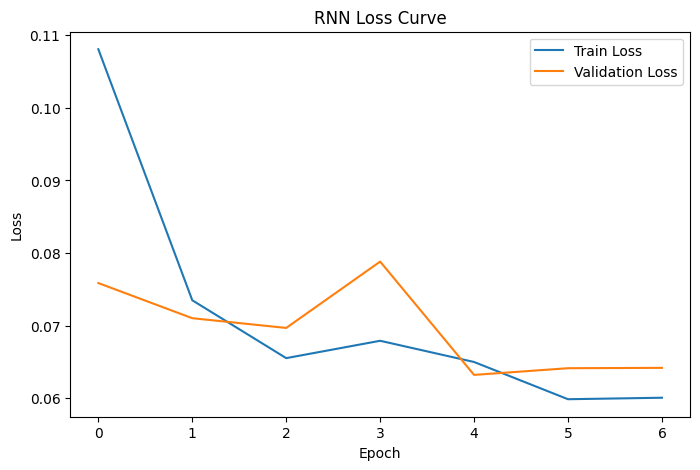

In [219]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

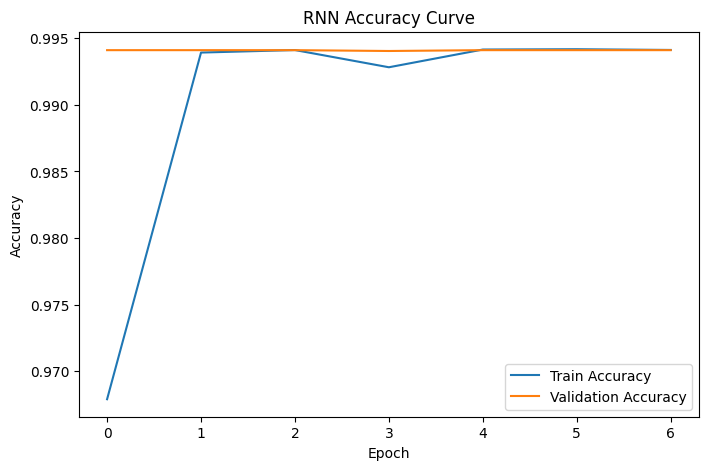

In [220]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("RNN Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [221]:
#bilstm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dropout

bilstm_model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=200
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    Dropout(0.3),

    Bidirectional(
        LSTM(
            64
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        6,
        activation='sigmoid'
    )

])

bilstm_model.compile(
    optimizer='adam',
loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(),
        Recall()
    ]
)
bilstm_model.build(input_shape=(None, 200))
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 200, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,718,054 (6.55 MB)

 Trainable params: 1,718,054 (6.55 MB)

 Non-trainable params: 0 (0.00 B)

In [222]:
#trainbilstm
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 153s 37ms/step - accuracy: 0.9824 - loss: 0.0669 - precision_7: 0.7851 - recall_7: 0.5551 - val_accuracy: 0.9941 - val_loss: 0.0530 - val_precision_7: 0.7898 - val_recall_7: 0.6739
Epoch 2/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 150s 38ms/step - accuracy: 0.9878 - loss: 0.0509 - precision_7: 0.8161 - recall_7: 0.6440 - val_accuracy: 0.9941 - val_loss: 0.0523 - val_precision_7: 0.8500 - val_recall_7: 0.5975
Epoch 3/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 148s 37ms/step - accuracy: 0.9873 - loss: 0.0471 - precision_7: 0.8204 - recall_7: 0.6689 - val_accuracy: 0.9941 - val_loss: 0.0521 - val_precision_7: 0.8182 - val_recall_7: 0.6452
Epoch 4/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 203s 37ms/step - accuracy: 0.9564 - loss: 0.0433 - precision_7: 0.8314 - recall_7: 0.6975 - val_accuracy: 0.9941 - val_loss: 0.0530 - val_precision_7: 0.7962 - val_recall_7: 0.6692
Epoch 5/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 152s 38ms/step - accuracy: 0.9830 - loss: 0.0398 - precision_7: 0.8362 

In [223]:
#best epoch is 3

In [224]:
from sklearn.metrics import f1_score

bilstm_pred = bilstm_model.predict(X_test)

bilstm_pred = (
    bilstm_pred > 0.3
).astype(int)

f1 = f1_score(
    y_test,
    bilstm_pred,
    average='macro'
)

print("Macro F1 Score:", f1)

998/998 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step
Macro F1 Score: 0.4641508621152957


In [225]:
bilstm_loss, bilstm_acc, bilstm_precision, bilstm_recall = bilstm_model.evaluate(
    X_test,
    y_test
)

print("BiLSTM Loss :", bilstm_loss)
print("BiLSTM Accuracy :", bilstm_acc)
print("BiLSTM Precision :", bilstm_precision)
print("BiLSTM Recall :", bilstm_recall)

998/998 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9941 - loss: 0.0521 - precision_7: 0.8182 - recall_7: 0.6452
BiLSTM Loss : 0.052126843482255936
BiLSTM Accuracy : 0.9941093325614929
BiLSTM Precision : 0.8182144165039062
BiLSTM Recall : 0.6451795101165771


In [227]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        bilstm_pred,
        target_names=[
            'toxic',
            'severe_toxic',
            'obscene',
            'threat',
            'insult',
            'identity_hate'
        ]
    )
)

               precision    recall  f1-score   support

        toxic       0.78      0.79      0.78      3056
 severe_toxic       0.46      0.52      0.49       321
      obscene       0.77      0.85      0.81      1715
       threat       0.00      0.00      0.00        74
       insult       0.66      0.77      0.71      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.73      0.74      0.74      7074
    macro avg       0.44      0.49      0.46      7074
 weighted avg       0.69      0.74      0.72      7074
  samples avg       0.06      0.07      0.06      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [228]:
from sklearn.metrics import multilabel_confusion_matrix

cm = multilabel_confusion_matrix(
    y_test,
    bilstm_pred
)

print(cm)

[[[28167   692]
  [  651  2405]]

 [[31397   197]
  [  155   166]]

 [[29760   440]
  [  262  1453]]

 [[31841     0]
  [   74     0]]

 [[29670   631]
  [  372  1242]]

 [[31621     0]
  [  294     0]]]


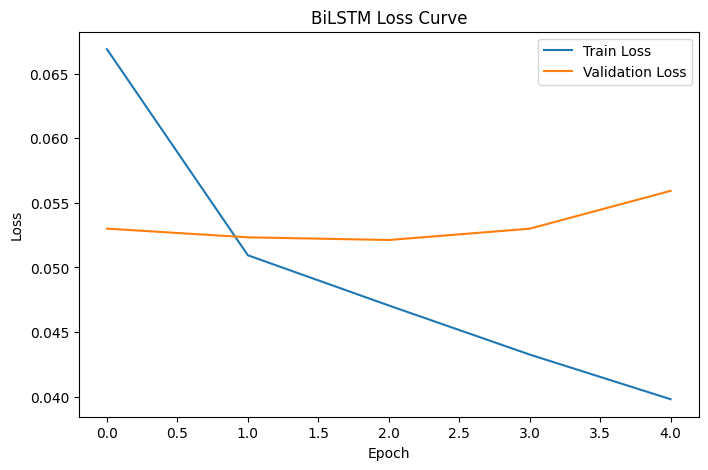

In [229]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_bilstm.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Loss Curve")

plt.legend()

plt.show()

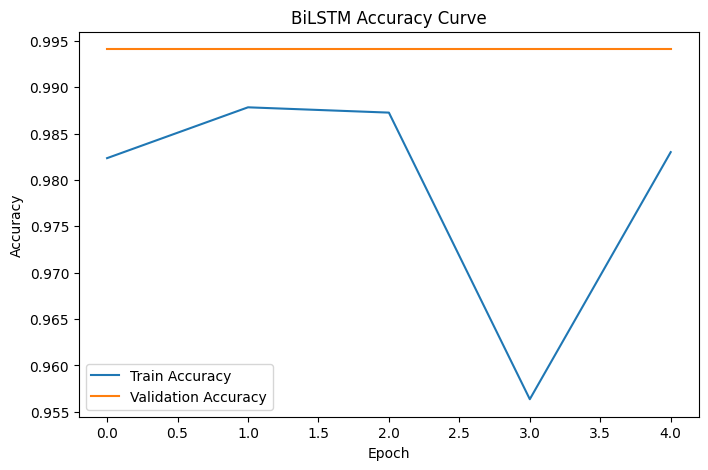

In [230]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_bilstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Accuracy Curve")

plt.legend()

plt.show()

In [231]:
#compare
rnn_loss, rnn_acc, rnn_precision, rnn_recall = rnn_model.evaluate(
    X_test,
    y_test
)

print("RNN Accuracy :", rnn_acc)
print("BiLSTM Accuracy :", bilstm_acc)

998/998 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9941 - loss: 0.0632 - precision_6: 0.8178 - recall_6: 0.5551
RNN Accuracy : 0.9941093325614929
BiLSTM Accuracy : 0.9941093325614929


In [236]:
bilstm_model.save(
    "bilstm_toxicity.keras"
)